# 🔢 Feature Extraction: TF-IDF

## Convertir Texto en Números para Machine Learning

En este notebook aprenderás cómo convertir **texto limpio → vectores numéricos** que los modelos de ML pueden procesar.

### Objetivos del Notebook:
1. **Entender Bag of Words (BoW)** - Representación simple
2. **Aprender TF-IDF** - Representación ponderada
3. **Calcular TF-IDF manualmente** - Entender la fórmula
4. **Usar sklearn TfidfVectorizer** - Implementación práctica
5. **Analizar features importantes** - Qué palabras importan más
6. **Comparar diferentes parámetros** - max_features, ngrams, etc.
7. **Visualizar resultados** - Gráficos informativos

### ¿Por qué convertir texto a números?

Los algoritmos de ML solo entienden números. Necesitamos convertir:
```
Texto:    "This movie is amazing!"
Vector:   [0, 1, 0, 0, 1, 1, 0, ...] (0s y 1s en matriz)
o
Vector:   [0, 2.5, 0, 0, 3.2, 1.8, 0, ...] (números ponderados)
```

Cada posición en el vector representa una palabra única del vocabulario.

## Parte 1: Configuración Inicial

In [15]:
# Importar librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re
from collections import Counter
import math

# Machine Learning
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import normalize

# Configurar visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
%matplotlib inline

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


In [16]:
# Configurar rutas del proyecto
NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR.parent
DATA_RAW_DIR = PROJECT_DIR / 'data' / 'raw'
REPORTS_DIR = PROJECT_DIR / 'reports'

# Crear directorios si no existen
DATA_RAW_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"📁 Rutas configuradas")
print(f"   - Proyecto: {PROJECT_DIR}")
print(f"   - Reportes: {REPORTS_DIR}")

📁 Rutas configuradas
   - Proyecto: /
   - Reportes: /reports


## Parte 2: Ejemplos de Documentos

In [17]:
# CARGAR Y PREPARAR DATASET IMDB REAL
print("=" * 70)
print("📥 CARGANDO Y PREPARANDO DATASET IMDB")
print("=" * 70)

from tensorflow.keras.datasets import imdb
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import nltk

# Descargar recursos NLTK
print("\n⏳ Descargando recursos...")
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

# Cargar dataset IMDB
print("⏳ Cargando dataset IMDB...")
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=10000)

# Obtener diccionario de palabras
word_index = imdb.get_word_index()
reverse_word_index = {v: k for k, v in word_index.items()}

# Función para decodificar reviews
def decode_review(encoded_review, reverse_word_index):
    """Convierte review tokenizada (números) a texto."""
    decoded_text = ""
    for word_idx in encoded_review:
        if word_idx >= 3:
            decoded_text += " " + reverse_word_index.get(word_idx, "<unknown>")
    return decoded_text.strip()

# Función para preprocesar texto
def preprocess_review(text):
    """Limpia y prepara el texto."""
    import re
    # Convertir a minúsculas
    text = text.lower()
    # Remover caracteres especiales
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenizar
    tokens = word_tokenize(text)
    # Remover stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]
    return ' '.join(tokens)

# Seleccionar muestras del IMDB para demostración
print("✅ Dataset cargado")
print(f"   - Training: {len(X_train)} reviews")
print(f"   - Test: {len(X_test)} reviews")

# Obtener reviews positivas y negativas
positive_indices = [i for i, label in enumerate(y_train[:500]) if label == 1][:5]
negative_indices = [i for i, label in enumerate(y_train[:500]) if label == 0][:5]

# Decodificar y preprocesar
print("\n⏳ Preprocesando muestras...")
documents = []
labels_docs = []

for idx in positive_indices:
    decoded = decode_review(X_train[idx], reverse_word_index)
    processed = preprocess_review(decoded)
    documents.append(processed)
    labels_docs.append(1)

for idx in negative_indices:
    decoded = decode_review(X_train[idx], reverse_word_index)
    processed = preprocess_review(decoded)
    documents.append(processed)
    labels_docs.append(0)

print(f"✅ {len(documents)} reviews procesadas (5 positivas + 5 negativas)\n")

# Mostrar primeras líneas
print("=" * 70)
print("📝 EJEMPLOS DE REVIEWS PROCESADAS (IMDB REAL)")
print("=" * 70)

for i, (doc, label) in enumerate(zip(documents[:3], labels_docs[:3]), 1):
    sentiment = "Positiva ✅" if label == 1 else "Negativa ❌"
    doc_display = doc if len(doc) <= 100 else doc[:100] + "..."
    print(f"\n{i}. {sentiment}")
    print(f"   {doc_display}")

📥 CARGANDO Y PREPARANDO DATASET IMDB

⏳ Descargando recursos...
⏳ Cargando dataset IMDB...
✅ Dataset cargado
   - Training: 25000 reviews
   - Test: 25000 reviews

⏳ Preprocesando muestras...
✅ 10 reviews procesadas (5 positivas + 5 negativas)

📝 EJEMPLOS DE REVIEWS PROCESADAS (IMDB REAL)

1. Positiva ✅
   powerful lets loves becomes reaching journalist lot anyone atmosphere never room heart shows years e...

2. Positiva ✅
   halfway identity went plot actors watch share well ten failing feels novak killer theo bill br would...

3. Positiva ✅
   boiled full involving impressive boring murdering naschy br villain suggestion need costumes message...


## Parte 3: Bag of Words (BoW)

### Concepto
**Bag of Words** es la representación más simple: cuenta cuántas veces aparece cada palabra en cada documento.

**Ejemplo:**
```
Documento 1: "movie amazing excellent best"
Documento 2: "terrible bad waste time"

Vocabulario: [movie, amazing, excellent, best, terrible, bad, waste, time]
Doc 1 BoW:   [1, 1, 1, 1, 0, 0, 0, 0]
Doc 2 BoW:   [0, 0, 0, 0, 1, 1, 1, 1]
```

In [18]:
print("=" * 70)
print("📊 BAG OF WORDS (BOW)")
print("=" * 70)

# Crear BoW manualmente
vectorizer_bow = CountVectorizer()
bow_matrix = vectorizer_bow.fit_transform(documents)
bow_array = bow_matrix.toarray()
feature_names = vectorizer_bow.get_feature_names_out()

print(f"\n📚 Vocabulario ({len(feature_names)} palabras únicas):")
print(f"  {list(feature_names)}")

# Crear DataFrame para visualizar mejor
bow_df = pd.DataFrame(
    bow_array,
    columns=feature_names,
    index=[f'Doc {i+1}' for i in range(len(documents))]
)

print(f"\n📊 Matriz BoW:")
print(bow_df)

print(f"\n💡 Interpretación:")
print(f"  - Cada fila es un documento")
print(f"  - Cada columna es una palabra del vocabulario")
print(f"  - Los valores son frecuencias (cuántas veces aparece cada palabra)")

📊 BAG OF WORDS (BOW)

📚 Vocabulario (729 palabras únicas):
  ['absolutely', 'accent', 'accepted', 'accidentally', 'across', 'acting', 'action', 'actor', 'actors', 'actual', 'actually', 'aka', 'alexandre', 'aliens', 'alive', 'alleged', 'almost', 'along', 'already', 'also', 'although', 'always', 'american', 'andy', 'animals', 'another', 'antonioni', 'anxious', 'anyone', 'anything', 'anyway', 'appears', 'arab', 'armed', 'around', 'arts', 'assassin', 'assumed', 'atmosphere', 'attempt', 'attention', 'average', 'awaiting', 'away', 'back', 'bad', 'barrel', 'basic', 'bauer', 'beautiful', 'beckinsale', 'become', 'becomes', 'becoming', 'begins', 'best', 'better', 'bible', 'big', 'bill', 'bit', 'bland', 'blatantly', 'blockbuster', 'blood', 'blues', 'boat', 'bodies', 'body', 'boiled', 'bond', 'bonus', 'book', 'boring', 'boss', 'bound', 'boys', 'br', 'broad', 'brosnan', 'brother', 'budget', 'burgess', 'camera', 'camp', 'cant', 'captures', 'car', 'care', 'carl', 'carmen', 'cast', 'cause', 'caused', 

## Parte 4: TF-IDF Explicado

### Problema con Bag of Words
BoW trata todas las palabras igual. Pero algunas palabras son más importantes que otras:
- Palabras comunes ("the", "is", "a") aparecen en todos los documentos → poco útiles
- Palabras raras ("masterpiece") aparecen en pocos documentos → muy útiles

### TF-IDF (Term Frequency - Inverse Document Frequency)

**Fórmula:**
```
TF-IDF(word, doc) = TF(word, doc) × IDF(word)

TF (Term Frequency) = Frecuencia de la palabra en el documento
IDF (Inverse Document Frequency) = log(Total docs / Docs con la palabra)
```

**Interpretación:**
- TF: ¿Qué tan frecuente es esta palabra en este documento?
- IDF: ¿Qué tan rara es esta palabra en toda la colección?
- TF-IDF alto: Palabra frecuente en este doc pero rara en otros → **muy importante**
- TF-IDF bajo: Palabra común en todos → poco importante

In [19]:
print("=" * 70)
print("📐 CÁLCULO MANUAL DE TF-IDF")
print("=" * 70)

# Calcular TF-IDF manualmente para aprender
def calculate_tf_idf_manual(documents):
    """
    Calcula TF-IDF manualmente para entender la fórmula.
    """
    # 1. Crear vocabulario
    vocabulary = set()
    for doc in documents:
        vocabulary.update(doc.split())
    vocabulary = sorted(list(vocabulary))
    
    # 2. Calcular TF para cada documento
    tf_matrix = []
    for doc in documents:
        words = doc.split()
        tf = {}
        doc_length = len(words)
        for word in vocabulary:
            # TF = frecuencia / total palabras
            tf[word] = words.count(word) / doc_length if doc_length > 0 else 0
        tf_matrix.append(tf)
    
    # 3. Calcular IDF
    idf = {}
    total_docs = len(documents)
    for word in vocabulary:
        docs_with_word = sum(1 for doc in documents if word in doc.split())
        # IDF = log(total_docs / docs_con_palabra)
        idf[word] = math.log(total_docs / docs_with_word) if docs_with_word > 0 else 0
    
    # 4. Calcular TF-IDF
    tfidf_matrix = []
    for tf in tf_matrix:
        tfidf = {word: tf[word] * idf[word] for word in vocabulary}
        tfidf_matrix.append(tfidf)
    
    return vocabulary, tf_matrix, idf, tfidf_matrix

vocabulary, tf_matrix, idf, tfidf_matrix = calculate_tf_idf_manual(documents)

print("\n1️⃣  IDF (Inverse Document Frequency) de cada palabra:")
print("   (Palabras raras tienen IDF alto, palabras comunes tienen IDF bajo)\n")
for word in vocabulary:
    print(f"   {word:<15} IDF: {idf[word]:6.3f}")

print("\n2️⃣  TF para Documento 1 ('movie amazing excellent best'):")
print(f"\n   {tf_matrix[0]}")

print("\n3️⃣  TF-IDF para Documento 1:")
print(f"\n   {tfidf_matrix[0]}")

📐 CÁLCULO MANUAL DE TF-IDF

1️⃣  IDF (Inverse Document Frequency) de cada palabra:
   (Palabras raras tienen IDF alto, palabras comunes tienen IDF bajo)

   absolutely      IDF:  2.303
   accent          IDF:  2.303
   accepted        IDF:  2.303
   accidentally    IDF:  2.303
   across          IDF:  2.303
   acting          IDF:  0.916
   action          IDF:  2.303
   actor           IDF:  2.303
   actors          IDF:  1.609
   actual          IDF:  2.303
   actually        IDF:  2.303
   aka             IDF:  2.303
   alexandre       IDF:  2.303
   aliens          IDF:  2.303
   alive           IDF:  1.609
   alleged         IDF:  2.303
   almost          IDF:  2.303
   along           IDF:  1.609
   already         IDF:  2.303
   also            IDF:  0.693
   although        IDF:  2.303
   always          IDF:  1.204
   american        IDF:  2.303
   andy            IDF:  2.303
   animals         IDF:  2.303
   another         IDF:  2.303
   antonioni       IDF:  2.303
   anxiou

## Parte 5: TF-IDF con sklearn

In [20]:
print("=" * 70)
print("🚀 TF-IDF CON SKLEARN")
print("=" * 70)

# Crear vectorizador TF-IDF
vectorizer_tfidf = TfidfVectorizer()
tfidf_matrix = vectorizer_tfidf.fit_transform(documents)
tfidf_array = tfidf_matrix.toarray()
feature_names = vectorizer_tfidf.get_feature_names_out()

# Crear DataFrame para visualizar
tfidf_df = pd.DataFrame(
    tfidf_array,
    columns=feature_names,
    index=[f'Doc {i+1}' for i in range(len(documents))]
)

print(f"\n📊 Matriz TF-IDF:")
print(tfidf_df.round(3))

print(f"\n💡 Observaciones:")
print(f"  - Cada valor está entre 0 y 1 (normalizado)")
print(f"  - Palabras que aparecen en muchos docs tienen TF-IDF bajo")
print(f"  - Palabras únicas de cada doc tienen TF-IDF alto")

🚀 TF-IDF CON SKLEARN

📊 Matriz TF-IDF:
        absolutely  accent  accepted  accidentally  across  acting  action  \
Doc 1        0.000   0.000     0.000         0.000   0.000   0.074   0.000   
Doc 2        0.000   0.000     0.000         0.045   0.045   0.030   0.000   
Doc 3        0.000   0.000     0.000         0.000   0.000   0.000   0.000   
Doc 4        0.000   0.000     0.000         0.000   0.000   0.000   0.000   
Doc 5        0.000   0.000     0.056         0.000   0.000   0.000   0.056   
Doc 6        0.000   0.000     0.000         0.000   0.000   0.000   0.000   
Doc 7        0.000   0.000     0.000         0.000   0.000   0.091   0.000   
Doc 8        0.000   0.000     0.000         0.000   0.000   0.155   0.000   
Doc 9        0.000   0.000     0.000         0.000   0.000   0.000   0.000   
Doc 10       0.161   0.054     0.000         0.000   0.000   0.000   0.000   

        actor  actors  actual  ...  worthwhile  would  write  writer  wrong  \
Doc 1   0.000   0.000  

## Parte 6: Comparación BoW vs TF-IDF

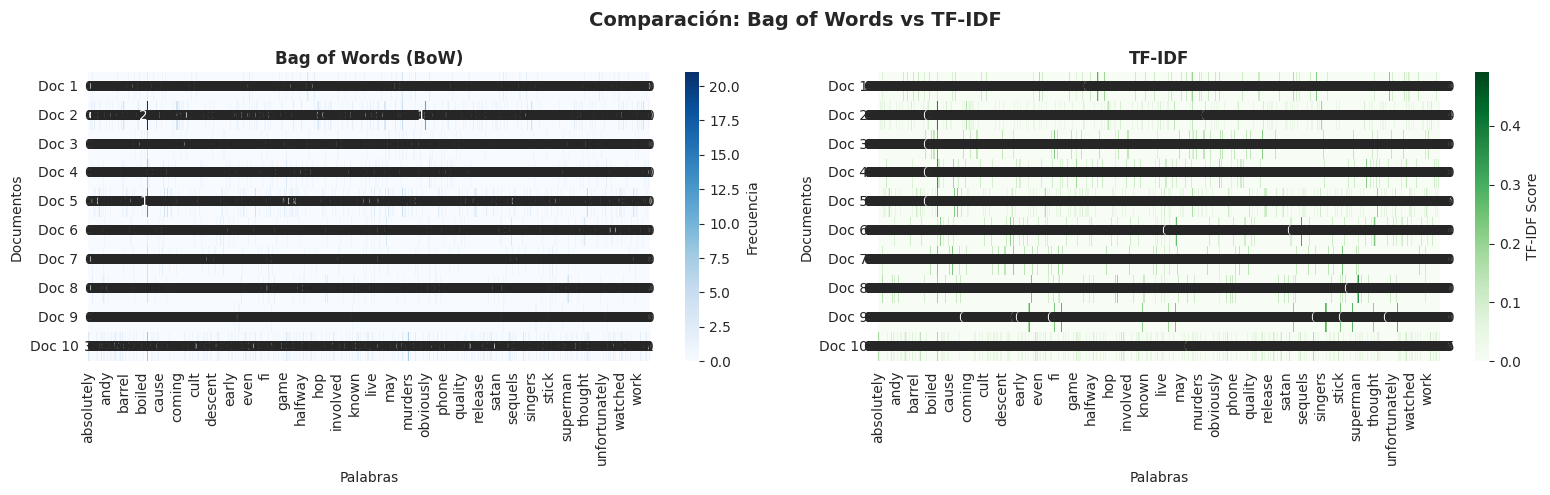

✅ Visualización guardada


In [21]:
# Visualizar comparación
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Comparación: Bag of Words vs TF-IDF', fontsize=14, fontweight='bold')

# BoW
ax1 = axes[0]
sns.heatmap(bow_df, annot=True, fmt='.0f', cmap='Blues', ax=ax1, cbar_kws={'label': 'Frecuencia'})
ax1.set_title('Bag of Words (BoW)', fontweight='bold')
ax1.set_xlabel('Palabras')
ax1.set_ylabel('Documentos')

# TF-IDF
ax2 = axes[1]
sns.heatmap(tfidf_df, annot=True, fmt='.2f', cmap='Greens', ax=ax2, cbar_kws={'label': 'TF-IDF Score'})
ax2.set_title('TF-IDF', fontweight='bold')
ax2.set_xlabel('Palabras')
ax2.set_ylabel('Documentos')

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'bow_vs_tfidf.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Visualización guardada")

## Parte 7: Palabras Más Importantes por Documento

In [22]:
print("=" * 70)
print("⭐ PALABRAS MÁS IMPORTANTES POR DOCUMENTO")
print("=" * 70)

# Analizar cada documento
for doc_idx, (doc, row) in enumerate(zip(documents, tfidf_array), 1):
    print(f"\n📝 Documento {doc_idx}: '{doc}'")
    print("-" * 70)
    
    # Obtener índices de palabras ordenadas por TF-IDF
    top_indices = np.argsort(row)[::-1][:5]  # Top 5 palabras
    
    print(f"\nTop 5 palabras más importantes:")
    for rank, idx in enumerate(top_indices, 1):
        word = feature_names[idx]
        score = row[idx]
        bar = '█' * int(score * 50)
        print(f"   {rank}. {word:<15} {score:.4f} {bar}")

⭐ PALABRAS MÁS IMPORTANTES POR DOCUMENTO

📝 Documento 1: 'powerful lets loves becomes reaching journalist lot anyone atmosphere never room heart shows years every never going help moments every chest visual movie except several enough current film mine potentially unfortunately get camp movie sometimes movie scary story wonderful seeing character musicians heart shadows serious critics isnt one seen landed anyone br shows whether history name half br odd two mean boat thought frog script history heart real barrel one bit two script nobody wasnt armed acting watch heartfelt film want'
----------------------------------------------------------------------

Top 5 palabras más importantes:
   1. heart           0.2844 ██████████████
   2. shows           0.2230 ███████████
   3. two             0.2230 ███████████
   4. anyone          0.2230 ███████████
   5. movie           0.1986 █████████

📝 Documento 2: 'halfway identity went plot actors watch share well ten failing feels novak killer 

## Parte 8: Parámetros de TfidfVectorizer

In [23]:
print("=" * 70)
print("⚙️  PARÁMETROS DE TFIDFVECTORIZER")
print("=" * 70)

# Probar diferentes max_features
max_features_values = [None, 3, 5, 10]

for max_feat in max_features_values:
    vec = TfidfVectorizer(max_features=max_feat)
    matrix = vec.fit_transform(documents)
    print(f"\nmax_features={max_feat}:")
    print(f"   - Vocabulario: {len(vec.get_feature_names_out())} palabras")
    print(f"   - Palabras: {list(vec.get_feature_names_out())[:10]}")

⚙️  PARÁMETROS DE TFIDFVECTORIZER

max_features=None:
   - Vocabulario: 729 palabras
   - Palabras: ['absolutely', 'accent', 'accepted', 'accidentally', 'across', 'acting', 'action', 'actor', 'actors', 'actual']

max_features=3:
   - Vocabulario: 3 palabras
   - Palabras: ['br', 'film', 'movie']

max_features=5:
   - Vocabulario: 5 palabras
   - Palabras: ['br', 'film', 'movie', 'obviously', 'one']

max_features=10:
   - Vocabulario: 10 palabras
   - Palabras: ['br', 'film', 'get', 'movie', 'music', 'obviously', 'one', 'show', 'time', 'want']


In [24]:
print("\n" + "=" * 70)
print("📚 PARÁMETRO: ngram_range")
print("=" * 70)

print("\n1️⃣  unigrams (palabras individuales):")
vec_uni = TfidfVectorizer(ngram_range=(1, 1), max_features=10)
vec_uni.fit(documents)
print(f"   {list(vec_uni.get_feature_names_out())}")

print("\n2️⃣  bigrams (pares de palabras):")
vec_bi = TfidfVectorizer(ngram_range=(2, 2), max_features=10)
vec_bi.fit(documents)
print(f"   {list(vec_bi.get_feature_names_out())}")

print("\n3️⃣  unigrams + bigrams:")
vec_both = TfidfVectorizer(ngram_range=(1, 2), max_features=10)
vec_both.fit(documents)
print(f"   {list(vec_both.get_feature_names_out())[:10]}")

print("\n💡 Los bigrams capturan frases: 'movie amazing' es más específico que 'movie'")


📚 PARÁMETRO: ngram_range

1️⃣  unigrams (palabras individuales):
   ['br', 'film', 'get', 'movie', 'music', 'obviously', 'one', 'show', 'time', 'want']

2️⃣  bigrams (pares de palabras):
   ['along wrong', 'br singers', 'lot br', 'obviously obviously', 'one want', 'plot actors', 'routines entirely', 'solid thought', 'time done', 'together br']

3️⃣  unigrams + bigrams:
   ['br', 'film', 'get', 'movie', 'music', 'obviously', 'one', 'show', 'time', 'want']

💡 Los bigrams capturan frases: 'movie amazing' es más específico que 'movie'


## Parte 9: Análisis de Vocabulario

In [25]:
print("=" * 70)
print("📚 ANÁLISIS DE VOCABULARIO")
print("=" * 70)

# Calcular frecuencias globales
global_tfidf = tfidf_df.sum(axis=0).sort_values(ascending=False)

print(f"\n📊 Palabras por importancia global (suma de TF-IDF):")
for word, score in global_tfidf.items():
    bar = '█' * int(score * 20)
    print(f"   {word:<15} {score:.4f} {bar}")

print(f"\n💡 Palabras con mayor importancia global:")
print(f"   - Tienden a ser palabras discriminativas")
print(f"   - Aparecen en pocos documentos pero son muy importantes en ellos")

📚 ANÁLISIS DE VOCABULARIO

📊 Palabras por importancia global (suma de TF-IDF):
   br              2.0441 ████████████████████████████████████████
   film            0.6880 █████████████
   movie           0.6390 ████████████
   one             0.5401 ██████████
   sure            0.5277 ██████████
   obviously       0.4910 █████████
   get             0.4620 █████████
   female          0.4607 █████████
   script          0.4587 █████████
   dont            0.4577 █████████
   show            0.4170 ████████
   time            0.3855 ███████
   want            0.3791 ███████
   heart           0.3742 ███████
   music           0.3669 ███████
   though          0.3620 ███████
   making          0.3559 ███████
   thought         0.3557 ███████
   lot             0.3525 ███████
   acting          0.3487 ██████
   also            0.3481 ██████
   look            0.3474 ██████
   im              0.3401 ██████
   never           0.3386 ██████
   still           0.3347 ██████
   stories      

## Parte 10: Aplicación Práctica con Más Documentos

In [26]:
# ANÁLISIS PRÁCTICO CON DATASET IMDB
print("=" * 70)
print("🎬 ANÁLISIS PRÁCTICO: REVIEWS DE PELÍCULAS (IMDB REAL)")
print("=" * 70)

# Usamos los documents que ya cargamos desde IMDB
print(f"\n📊 Dataset para análisis:")
print(f"   - Total documentos: {len(documents)}")
print(f"   - Positivas: {sum(labels_docs)}")
print(f"   - Negativas: {len(labels_docs) - sum(labels_docs)}")

# Crear vectorizador
vec_practical = TfidfVectorizer(max_features=30)
matrix_practical = vec_practical.fit_transform(documents)
array_practical = matrix_practical.toarray()
features_practical = vec_practical.get_feature_names_out()

# Crear DataFrame
df_practical = pd.DataFrame(
    array_practical,
    columns=features_practical,
    index=[f"Review {i+1} {'✅' if label == 1 else '❌'}" for i, label in enumerate(labels_docs)]
)

print(f"\n📊 Matriz TF-IDF ({len(documents)} documentos, {len(features_practical)} features):")
print(df_practical.round(3))

print(f"\n🎯 Palabras más discriminativas en el dataset IMDB:")
word_importance = df_practical.sum(axis=0).sort_values(ascending=False)
for word, score in word_importance.head(15).items():
    bar = '█' * int(score * 15)
    print(f"   {word:<15} {score:.2f} {bar}")

🎬 ANÁLISIS PRÁCTICO: REVIEWS DE PELÍCULAS (IMDB REAL)

📊 Dataset para análisis:
   - Total documentos: 10
   - Positivas: 5
   - Negativas: 5

📊 Matriz TF-IDF (10 documentos, 30 features):
             acting   also    bad   best     br   dont    end  enough   fact  \
Review 1 ✅    0.208  0.000  0.000  0.000  0.255  0.000  0.000   0.208  0.000   
Review 2 ✅    0.043  0.000  0.173  0.000  0.557  0.000  0.039   0.043  0.000   
Review 3 ✅    0.000  0.000  0.000  0.000  0.746  0.274  0.000   0.000  0.000   
Review 4 ✅    0.000  0.125  0.139  0.000  0.681  0.000  0.125   0.000  0.000   
Review 5 ✅    0.000  0.064  0.072  0.184  0.570  0.000  0.064   0.143  0.322   
Review 6 ❌    0.000  0.000  0.000  0.000  0.304  0.558  0.000   0.000  0.279   
Review 7 ❌    0.210  0.188  0.210  0.000  0.514  0.472  0.000   0.000  0.000   
Review 8 ❌    0.311  0.280  0.000  0.000  0.382  0.000  0.000   0.000  0.000   
Review 9 ❌    0.000  0.000  0.000  0.000  0.000  0.000  0.668   0.000  0.000   
Review 10 ❌

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/tmp/ipython-input-336993018.py:11: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(REPORTS_DIR / 'tfidf_matrix_practical.png', dpi=300, bbox_inches='tight')
/tmp/ipython-input-336993018.py:11: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(REPORTS_DIR / 'tfidf_matrix_practical.png', dpi=300, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools

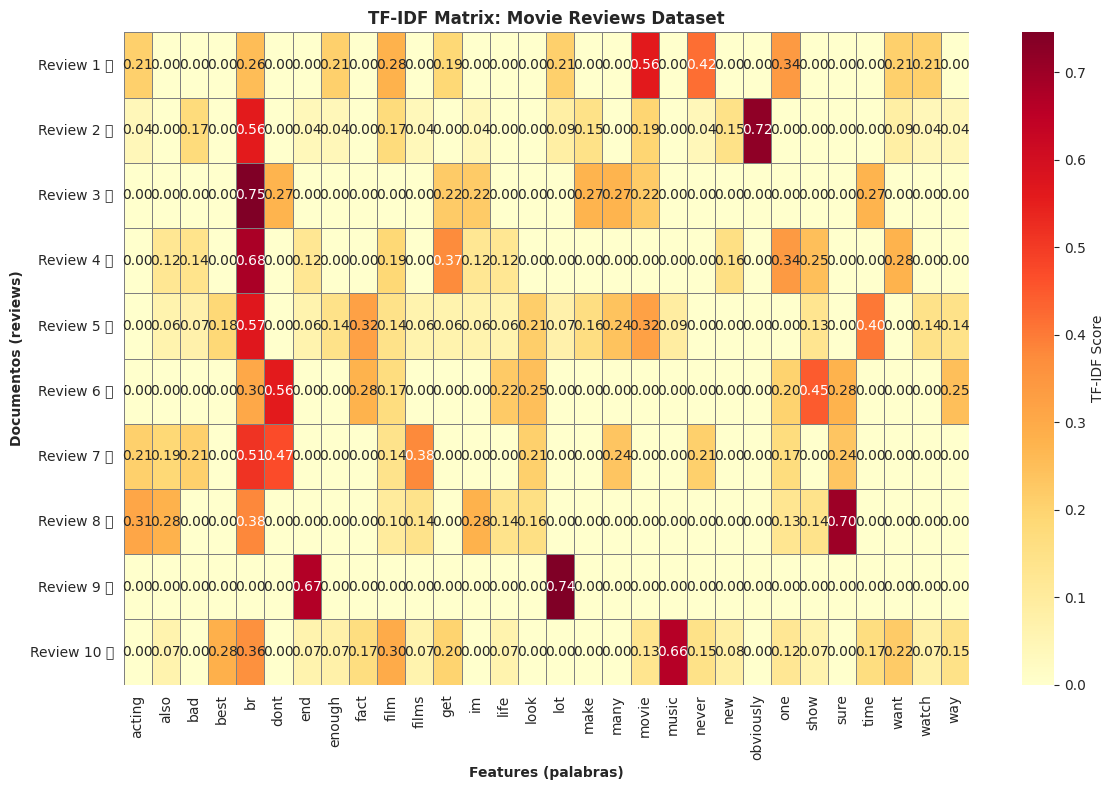

✅ Visualización guardada


In [27]:
# Visualizar matriz con más documentos
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(df_practical, annot=True, fmt='.2f', cmap='YlOrRd', 
            ax=ax, cbar_kws={'label': 'TF-IDF Score'},
            linewidths=0.5, linecolor='gray')
ax.set_title('TF-IDF Matrix: Movie Reviews Dataset', fontweight='bold', fontsize=12)
ax.set_xlabel('Features (palabras)', fontweight='bold')
ax.set_ylabel('Documentos (reviews)', fontweight='bold')

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'tfidf_matrix_practical.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Visualización guardada")

## Resumen y Conclusiones

### ✅ Lo que aprendimos:

1. **Bag of Words (BoW)**: Representación simple basada en frecuencias
   - Pros: Simple, fácil de entender
   - Contras: Trata todas las palabras igual

2. **TF-IDF**: Representación ponderada por importancia
   - TF: Frecuencia en el documento
   - IDF: Rareza en la colección
   - Resultado: Palabras discriminativas tienen scores altos

3. **Fórmula TF-IDF**:
   ```
   TF = frecuencia_palabra / total_palabras_documento
   IDF = log(total_documentos / documentos_con_palabra)
   TF-IDF = TF × IDF
   ```

4. **Parámetros Importantes**:
   - `max_features`: Limita vocabulario a N palabras más frecuentes
   - `ngram_range`: (1,1) unigrams, (2,2) bigrams, (1,2) ambos
   - `min_df`: Ignora palabras que aparecen en menos de X documentos
   - `max_df`: Ignora palabras que aparecen en más de X documentos

5. **Análisis de Features**:
   - Identificar palabras más importantes
   - Palabras discriminativas para clasificación
   - Reducción de ruido (stopwords)

### 🎯 Cuándo usar TF-IDF:

- ✅ **Modelos clásicos**: Naive Bayes, SVM, Logistic Regression
- ✅ **Búsqueda de texto**: Encontrar documentos relevantes
- ✅ **Clasificación**: Cuando necesitas features explícitas
- ✅ **Datasets pequeños a medianos**: Rápido y eficiente

- ❌ **Redes neuronales**: Mejor usar embeddings (Word2Vec, GloVe)
- ❌ **Capturar orden de palabras**: TF-IDF no preserva secuencia
- ❌ **Datasets muy grandes**: Considerar alternativas (Hashing)

### 🎓 Próximos pasos:

En el siguiente notebook:
- **Modelos Clásicos (ML)**
- Entrenar Naive Bayes y SVM con TF-IDF
- Evaluar y comparar modelos

In [28]:
# 🎮 Ejercicio Interactivo: Analizar con documentos IMDB reales
print("=" * 70)
print("🎮 EJERCICIO INTERACTIVO")
print("=" * 70)

# Usar una muestra más grande del IMDB
print(f"\n📊 Usando {len(documents)} documentos IMDB reales\n")

vec_interactive = TfidfVectorizer(max_features=20)
matrix_interactive = vec_interactive.fit_transform(documents)
array_interactive = matrix_interactive.toarray()

df_interactive = pd.DataFrame(
    array_interactive,
    columns=vec_interactive.get_feature_names_out(),
    index=[f'Review {i+1} {"✅" if label else "❌"}' for i, label in enumerate(labels_docs)]
)

print(f"📊 Matriz TF-IDF:")
print(df_interactive.round(3))

print(f"\n💡 Observaciones:")
print(f"   - Palabras en positivas (✅) suelen ser adjetivos favorables")
print(f"   - Palabras en negativas (❌) suelen ser adjetivos desfavorables")
print(f"   - TF-IDF captura bien la discriminación de sentimientos")

🎮 EJERCICIO INTERACTIVO

📊 Usando 10 documentos IMDB reales

📊 Matriz TF-IDF:
              also    bad     br   fact   film  films    get     im   look  \
Review 1 ✅   0.000  0.000  0.281  0.000  0.308  0.000  0.206  0.000  0.000   
Review 2 ✅   0.000  0.177  0.568  0.000  0.178  0.040  0.000  0.040  0.000   
Review 3 ✅   0.000  0.000  0.809  0.000  0.000  0.000  0.237  0.237  0.000   
Review 4 ✅   0.129  0.143  0.701  0.000  0.192  0.000  0.386  0.129  0.000   
Review 5 ✅   0.070  0.077  0.617  0.349  0.156  0.070  0.070  0.070  0.232   
Review 6 ❌   0.000  0.000  0.380  0.349  0.209  0.000  0.000  0.000  0.311   
Review 7 ❌   0.229  0.255  0.624  0.000  0.171  0.458  0.000  0.000  0.255   
Review 8 ❌   0.298  0.000  0.406  0.000  0.111  0.149  0.000  0.298  0.166   
Review 9 ❌   0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000   
Review 10 ❌  0.070  0.000  0.383  0.176  0.315  0.070  0.210  0.000  0.000   

              make  movie  music  never  obviously    one   sho